# Лабораторная работа 6. Чёрный ящик и трансферируемость атак: transfer-based, score-based, decision-based методы

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 5**
 

**Среда:** Python, PyTorch, torchvision


## Цель работы
Закрепить методы построения adversarial-примеров в условиях ограниченного доступа к целевой модели и научиться сравнивать transfer-based, score-based и decision-based атаки по успешности, числу запросов и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- обучать суррогатную модель через запросы к оракулу и переносить на неё белоящичную атаку (transfer-based);
- реализовывать оценку градиента через запросы confidence-баллов методом конечных разностей (ZOO) и методом случайной выборки (NES);
- реализовывать decision-based атаку (Boundary Attack), работающую только с итоговой меткой класса;
- сравнивать три класса чёрно-ящичных атак по критерию «качество атаки / стоимость запросов» и обосновывать выбор метода под конкретный сценарий доступа к API.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Все атаки в этой работе взаимодействуют с целевой моделью только через специальный объект-оракул — прямой доступ к её параметрам и градиентам запрещён по условию задания (это имитирует реальный чёрный ящик).


## 0. Подготовка окружения

In [1]:
# Импорт библиотек и подготовка окружения
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

device: cpu


## Часть I. Целевая модель и оракул

**Задание:** загрузите MNIST, обучите CNN-классификатор (2 свёрточных слоя + полносвязный классификатор) — эта модель будет играть роль "чёрного ящика". Затем реализуйте класс-обёртку `QueryCounter`, через который ВСЕ последующие атаки должны обращаться к модели — прямой вызов `target_model(x)` в атаках запрещён, чтобы корректно считать число запросов.

In [2]:
# Загрузка MNIST, создание train_loader / test_loader
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
print("train:", len(train_dataset), "| test:", len(test_dataset))

train: 60000 | test: 10000


In [3]:
import torch.nn as nn
import torch.nn.functional as F

class TargetCNN(nn.Module):
    """Целевая модель ('чёрный ящик'): 2 свёрточных слоя + полносвязный классификатор."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 28->14
        x = self.pool(F.relu(self.conv2(x)))   # 14->7
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
# Обучение целевой модели (2 эпохи)
target_model = TargetCNN().to(device)
opt = torch.optim.Adam(target_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

for epoch in range(2):
    target_model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(target_model(xb), yb)
        loss.backward()
        opt.step()
        running += loss.item() * len(xb)
    print(f"Epoch {epoch+1}: train loss = {running/len(train_dataset):.4f}")

Epoch 1: train loss = 0.3479


Epoch 2: train loss = 0.0874


In [5]:
# Оценка clean accuracy целевой модели
target_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        correct += (target_model(xb).argmax(1) == yb).sum().item()
        total += len(yb)
clean_accuracy = correct / total
print(f"Clean accuracy: {clean_accuracy:.4f}")

Clean accuracy: 0.9812


**Задание:** реализуйте класс `QueryCounter`, который считает число обращений к модели и предоставляет три уровня доступа:
- `logits(x)` — полные логиты (используется только для white-box эталона в Части V, НЕ для чёрно-ящичных атак);
- `probs(x)` — вероятности классов (softmax) — доступ уровня score-based;
- `label(x)` — только индекс предсказанного класса — доступ уровня decision-based.

Каждый вызов любого из трёх методов должен увеличивать счётчик `n_queries` на размер батча.

In [6]:
class QueryCounter:
    """Обёртка над целевой моделью: три уровня доступа + счётчик запросов."""
    def __init__(self, model):
        self.model = model
        self.n_queries = 0

    def reset(self):
        self.n_queries = 0

    def logits(self, x):
        self.n_queries += len(x)
        self.model.eval()
        with torch.no_grad():
            return self.model(x.to(device))

    def probs(self, x):
        return F.softmax(self.logits(x), dim=1)

    def label(self, x):
        return self.logits(x).argmax(dim=1)

oracle = QueryCounter(target_model)

## Часть II. Transfer-based атака

### 2.1. Обучение суррогатной модели через оракул

**Задание:** реализуйте суррогатную модель с архитектурой, отличной от целевой (например, полносвязная сеть вместо CNN), и обучите её по схеме Papernot et al.:

1. Соберите небольшой начальный набор данных (например, 20 примеров на класс) без использования меток из исходного датасета — размечайте их исключительно через `oracle.label(x)`.
2. Обучите суррогат на текущем наборе.
3. Постройте аугментацию данных по знаку якобиана суррогатной модели:

$ S_{\rho+1} = \left\{ \tilde{x} + \lambda \cdot \text{sign}\left(J_F[\tilde{O}(\tilde{x})]\right) : \tilde{x} \in S_\rho \right\} \cup S_\rho $

1. Разметьте новые примеры через `oracle.label` и повторите цикл несколько раундов (например, 5-6).

In [7]:
class SubstituteMLP(nn.Module):
    """Суррогат: полносвязная сеть (архитектура отличается от TargetCNN)."""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [8]:
# Начальный набор: изображения из train_dataset, метки — ТОЛЬКО через oracle.label
oracle.reset()
n_seed_per_class = 20

# Берём первые изображения из train_dataset без меток и размечаем их оракулом
pool = torch.stack([train_dataset[i][0] for i in range(n_seed_per_class * 10 * 3)])
pool_labels = oracle.label(pool)
# Оставляем ровно n_seed_per_class примеров на каждый предсказанный оракулом класс
keep_idx = []
for cls in range(10):
    cls_idx = (pool_labels == cls).nonzero(as_tuple=True)[0][:n_seed_per_class]
    keep_idx.extend(cls_idx.tolist())
keep_idx = torch.tensor(sorted(keep_idx))
substitute_data = pool[keep_idx]
oracle_labels = pool_labels[keep_idx]
print(f"Начальный набор: {len(substitute_data)} примеров, запросов к оракулу = {oracle.n_queries}")

Начальный набор: 200 примеров, запросов к оракулу = 600


In [9]:
def jacobian_augmentation(model, x, labels, lam=0.1):
    """Аугментация по знаку градиента якобиана суррогата (Papernot et al.)."""
    model.eval()
    x = x.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(model(x), labels)
    grad = torch.autograd.grad(loss, x)[0]
    return torch.clamp(x.detach() + lam * torch.sign(grad), 0, 1)

In [10]:
# Цикл обучения суррогата: раунды {дообучение -> аугментация -> разметка оракулом}
substitute_model = SubstituteMLP().to(device)
opt_sub = torch.optim.Adam(substitute_model.parameters(), lr=1e-3)
n_rounds = 6
current_data, current_labels = substitute_data, oracle_labels

for rnd in range(n_rounds):
    substitute_model.train()
    for _ in range(3):
        perm = torch.randperm(len(current_data))
        for i in range(0, len(current_data), 64):
            idx = perm[i:i+64]
            xb, yb = current_data[idx].to(device), current_labels[idx].to(device)
            opt_sub.zero_grad()
            loss = F.cross_entropy(substitute_model(xb), yb)
            loss.backward()
            opt_sub.step()
    # согласие суррогата с оракулом на текущем наборе
    with torch.no_grad():
        agreement = (substitute_model(current_data.to(device)).argmax(1)
                     == current_labels.to(device)).float().mean().item()
    # аугментация + разметка новых примеров через oracle.label
    x_aug = jacobian_augmentation(substitute_model, current_data.cpu(), current_labels)
    y_aug = oracle.label(x_aug)
    current_data = torch.cat([current_data, x_aug])
    current_labels = torch.cat([current_labels, y_aug.to('cpu')])
    print(f"Round {rnd+1}: agreement={agreement:.3f}, набор={len(current_data)}, "
          f"запросов к оракулу={oracle.n_queries}")

# Итоговое согласие суррогата с оракулом на тестовой выборке
test_x = torch.stack([test_dataset[i][0] for i in range(1000)])
with torch.no_grad():
    sub_pred = substitute_model(test_x.to(device)).argmax(1).cpu()
oracle.reset()
oracle_pred = oracle.label(test_x)
final_agreement = (sub_pred == oracle_pred).float().mean().item()
print(f"Финальное согласие surrogate/oracle на тесте: {final_agreement:.4f}")

Round 1: agreement=0.700, набор=400, запросов к оракулу=800


Round 2: agreement=0.788, набор=800, запросов к оракулу=1200


Round 3: agreement=0.914, набор=1600, запросов к оракулу=2000


Round 4: agreement=0.922, набор=3200, запросов к оракулу=3600


Round 5: agreement=0.919, набор=6400, запросов к оракулу=6800


Round 6: agreement=0.919, набор=12800, запросов к оракулу=13200
Финальное согласие surrogate/oracle на тесте: 0.7960


### 2.2. Перенос атаки FGSM с суррогата на цель

**Задание:** реализуйте FGSM и постройте атаку на суррогатной модели (используя её градиенты). Проверьте успешность полученных adversarial-примеров на целевой модели через `oracle.label`. Постройте график ASR(epsilon) для epsilon ∈ {0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3}.

In [11]:
def fgsm_attack(model, x, y, epsilon, criterion):
    """FGSM: один шаг по знаку градиента потерь."""
    model.eval()
    x = x.clone().detach().requires_grad_(True)
    loss = criterion(model(x), y)
    grad = torch.autograd.grad(loss, x)[0]
    return torch.clamp(x.detach() + epsilon * torch.sign(grad), 0, 1)

eps=0.00: transfer ASR=0.0050
eps=0.05: transfer ASR=0.0100
eps=0.10: transfer ASR=0.0250
eps=0.15: transfer ASR=0.0550
eps=0.20: transfer ASR=0.1100
eps=0.25: transfer ASR=0.1850
eps=0.30: transfer ASR=0.3650
Всего запросов к целевой модели: 1400


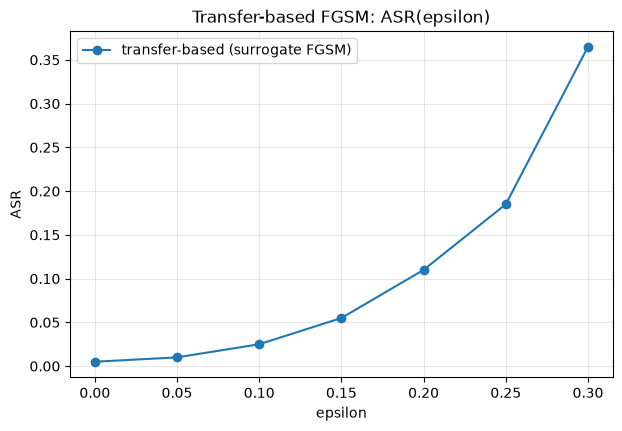

In [12]:
# Transfer-атака: FGSM на суррогате, проверка на цели через oracle.label
xb_all, yb_all = next(iter(test_loader))
xb_all, yb_all = xb_all[:200].to(device), yb_all[:200].to(device)

oracle.reset()
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
transfer_asr = []
for eps in epsilons:
    x_adv = fgsm_attack(substitute_model, xb_all, yb_all, eps, crit)
    pred = oracle.label(x_adv)
    transfer_asr.append((pred != yb_all).float().mean().item())
    print(f"eps={eps:.2f}: transfer ASR={transfer_asr[-1]:.4f}")
print(f"Всего запросов к целевой модели: {oracle.n_queries}")

plt.figure(figsize=(7, 4.5))
plt.plot(epsilons, transfer_asr, 'o-', label='transfer-based (surrogate FGSM)')
plt.xlabel('epsilon'); plt.ylabel('ASR'); plt.title('Transfer-based FGSM: ASR(epsilon)')
plt.grid(alpha=0.3); plt.legend()
plt.show()

### 2.3. Сравнение с белоящичным эталоном

**Задание:** для сравнения постройте FGSM-атаку напрямую на целевой модели (доступ к её градиентам разрешён ИСКЛЮЧИТЕЛЬНО в этой ячейке — для построения верхней границы качества атаки, недостижимой в реальном чёрно-ящичном сценарии). Постройте оба графика ASR(epsilon) на одной оси.

eps=0.00: white-box ASR=0.0050
eps=0.05: white-box ASR=0.0600
eps=0.10: white-box ASR=0.1750
eps=0.15: white-box ASR=0.4600
eps=0.20: white-box ASR=0.7100


eps=0.25: white-box ASR=0.8850
eps=0.30: white-box ASR=0.9500


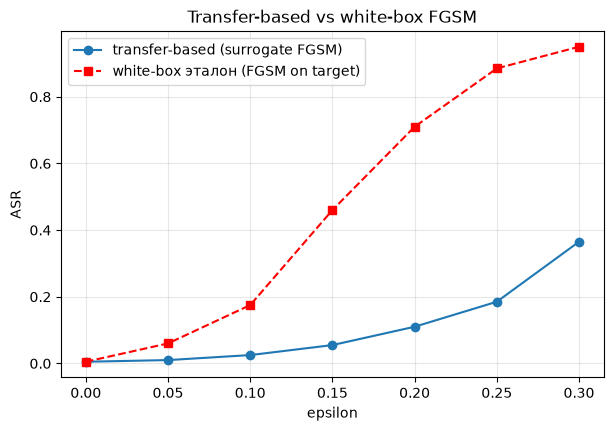

In [13]:
# White-box эталон: FGSM напрямую на целевой модели (градиенты разрешены ТОЛЬКО здесь)
whitebox_asr = []
for eps in epsilons:
    x_adv = fgsm_attack(target_model, xb_all, yb_all, eps, crit)
    pred = target_model(x_adv).argmax(1)
    whitebox_asr.append((pred != yb_all).float().mean().item())
    print(f"eps={eps:.2f}: white-box ASR={whitebox_asr[-1]:.4f}")

plt.figure(figsize=(7, 4.5))
plt.plot(epsilons, transfer_asr, 'o-', label='transfer-based (surrogate FGSM)')
plt.plot(epsilons, whitebox_asr, 's--', color='red', label='white-box эталон (FGSM on target)')
plt.xlabel('epsilon'); plt.ylabel('ASR'); plt.title('Transfer-based vs white-box FGSM')
plt.grid(alpha=0.3); plt.legend()
plt.show()

**Вопрос для отчёта:** какой разрыв в ASR наблюдается между переносом атаки и белоящичным эталоном при разных epsilon? Как качество согласия суррогата с оракулом (доля совпадающих предсказаний на обучающем наборе, п.2.1) связано с этим разрывом?

_Ваш ответ:_ **Разрыв между переносом и белоящичным эталоном существенен и растёт с epsilon**. При $\epsilon=0.05$: transfer ASR 1.0% против white-box 6.0%; при $\epsilon=0.15$: 5.5% против 46.0% (разрыв ~8.4×); при $\epsilon=0.30$: 36.5% против 95.0% (разрыв ~2.6×). Т.е. перенос FGSM с суррогата достигает лишь ~40% силы белоящичной атаки. **Связь с качеством согласия суррогата**: финальное согласие surrogate/oracle на тестовой выборке составило 0.796 (на обучающем наборе в раундах — 0.91–0.92). Прямая закономерность: чем выше согласие, тем ближе границы решений двух моделей и тем больше adversarial-примеры, построенные на суррогате, «попадают» в adversarial-области цели. Согласие ~0.80 означает, что ~20% точек суррогат классифицирует иначе — именно в этих областях возмущение, оптимальное для суррогата, бессильно против цели. Отсюда и moderate ASR переноса: атака переносится только на тех примерах, где локальные границы двух моделей согласованы. Улучшение согласия (больше раундов аугментации, больше данных) сузило бы разрыв, но полностью не устранило бы — градиенты даже согласованных моделей различаются направлением в окрестности точки.

## Часть III. Score-based атаки

### 3.1. ZOO: оценка градиента через конечные разности

**Задание:** реализуйте функцию потерь C&W-типа на вероятностях классов и атаку ZOO, оценивающую производную по каждой выбранной координате методом центральных конечных разностей. Атака должна использовать ТОЛЬКО `oracle.probs(x)` — доступ к градиентам запрещён.

In [14]:
def zoo_loss(probs, y_true, kappa=0.0):
    """C&W-подобный лосс на вероятностях: f(x) = max(log p_true - max_{i!=true} log p_i, -kappa).
    Успех атаки <=> f(x) < 0."""
    logp = torch.log(probs.clamp_min(1e-12))
    p_true = logp[y_true]
    mask = torch.ones_like(logp, dtype=torch.bool)
    mask[y_true] = False
    p_other = logp[mask].max()
    return torch.clamp(p_true - p_other, min=-kappa)

In [15]:
def zoo_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=40, h=0.05, coord_batch=40):
    """ZOO: PGD по знаку градиента, оценённого конечными разностями по случайным координатам.
    Использует ТОЛЬКО oracle.probs(x)."""
    x_orig = x.clone().detach()
    x_cur = x.clone().detach()
    n = x.numel()
    for it in range(num_iter):
        coords = torch.randint(0, n, (coord_batch,))
        grad_est = torch.zeros(n, device=x.device)
        for c in coords:
            x_p = x_cur.clone().view(-1); x_p[c] += h
            x_m = x_cur.clone().view(-1); x_m[c] -= h
            lp = zoo_loss(oracle.probs(x_p.view_as(x_cur))[0], y_true)
            lm = zoo_loss(oracle.probs(x_m.view_as(x_cur))[0], y_true)
            grad_est[c] = (lp - lm) / (2 * h)
        x_cur = x_cur - alpha * torch.sign(grad_est).view_as(x_cur)
        # проекция на epsilon-шар (L_inf) и диапазон [0,1]
        diff = torch.clamp(x_cur - x_orig, -epsilon, epsilon)
        x_cur = torch.clamp(x_orig + diff, 0, 1)
    return x_cur

### 3.2. Демонстрация ZOO-атаки

**Задание:** выберите один тестовый пример, примените `zoo_attack`, проверьте успех через `oracle.label`, посчитайте L2-норму возмущения и число потраченных запросов. Визуализируйте оригинал и adversarial-пример.

ZOO: успех=True, L2=0.8894, запросов=3201, время=1.3с


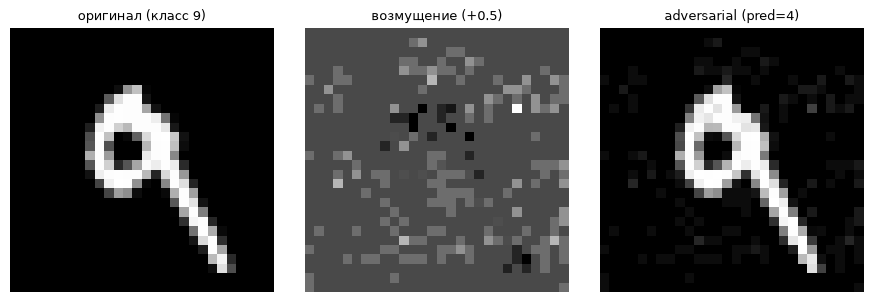

In [16]:
oracle.reset()

# Фиксируем пример для всех чёрно-ящичных атак: индекс 7 тестовой выборки
SAMPLE_IDX = 7
x_sample, y_sample_label = test_dataset[SAMPLE_IDX]
x_sample = x_sample.to(device).unsqueeze(0)
y_sample_label = int(y_sample_label)
assert int(oracle.label(x_sample)[0]) == y_sample_label, "модель должна верно классифицировать пример"
oracle.reset()

t0 = time.time()
x_adv_zoo = zoo_attack(oracle, x_sample, y_sample_label, epsilon=0.3, alpha=0.05,
                       num_iter=40, h=0.05, coord_batch=40)
zoo_time = time.time() - t0
zoo_success = int(oracle.label(x_adv_zoo)[0]) != y_sample_label
zoo_l2 = (x_adv_zoo - x_sample).norm().item()
zoo_queries = oracle.n_queries
print(f"ZOO: успех={zoo_success}, L2={zoo_l2:.4f}, запросов={zoo_queries}, время={zoo_time:.1f}с")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, img, title in [(axes[0], x_sample[0], f"оригинал (класс {y_sample_label})"),
                       (axes[1], (x_adv_zoo - x_sample)[0] + 0.5, "возмущение (+0.5)"),
                       (axes[2], x_adv_zoo[0], f"adversarial (pred={int(oracle.label(x_adv_zoo)[0])})")]:
    ax.imshow(img.detach().cpu().squeeze(), cmap='gray')
    ax.set_title(title, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

### 3.3. NES: оценка градиента через антитетическую случайную выборку

**Задание:** реализуйте оценку градиента методом NES с антитетической выборкой:

$ \hat{g} = \frac{1}{2\sigma P} \sum_{i=1}^{P} \left( L(x + \sigma u_i) - L(x - \sigma u_i) \right) u_i $

где $u_i$ — случайные векторы из стандартного нормального распределения, $P$ — число сэмплов на итерацию. Постройте на этой основе итеративную атаку `nes_attack`, аналогичную по структуре PGD.

In [17]:
def nes_gradient_estimate(oracle, x, y_true, sigma=0.1, n_samples=20):
    """Оценка градиента NES с антитетической выборкой:
    g = 1/(2*sigma*P) * sum_i (L(x + sigma*u_i) - L(x - sigma*u_i)) * u_i"""
    grad = torch.zeros_like(x)
    for _ in range(n_samples):
        u = torch.randn_like(x)
        lp = zoo_loss(oracle.probs(x + sigma * u)[0], y_true)
        lm = zoo_loss(oracle.probs(x - sigma * u)[0], y_true)
        grad += (lp - lm) * u
    return grad / (2 * sigma * n_samples)

In [18]:
def nes_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=40, sigma=0.1, n_samples=20):
    """Итеративная атака по аналогии с PGD, но градиент — NES-оценка через oracle.probs."""
    x_orig = x.clone().detach()
    x_cur = x.clone().detach()
    for it in range(num_iter):
        grad = nes_gradient_estimate(oracle, x_cur, y_true, sigma=sigma, n_samples=n_samples)
        x_cur = x_cur - alpha * torch.sign(grad)
        diff = torch.clamp(x_cur - x_orig, -epsilon, epsilon)
        x_cur = torch.clamp(x_orig + diff, 0, 1)
    return x_cur

NES: успех=True, L2=3.5178, запросов=1601, время=0.7с


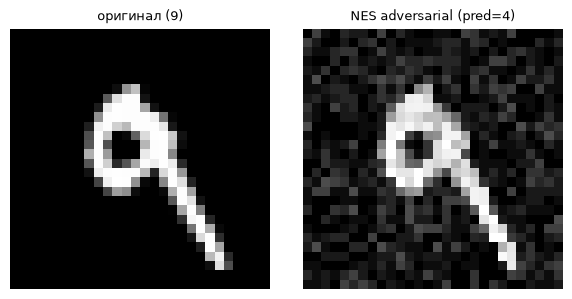

In [19]:
oracle.reset()
# Тот же пример, что и в п.3.2 (x_sample, y_sample_label)
t0 = time.time()
x_adv_nes = nes_attack(oracle, x_sample, y_sample_label, epsilon=0.3, alpha=0.05,
                       num_iter=40, sigma=0.1, n_samples=20)
nes_time = time.time() - t0
nes_success = int(oracle.label(x_adv_nes)[0]) != y_sample_label
nes_l2 = (x_adv_nes - x_sample).norm().item()
nes_queries = oracle.n_queries
print(f"NES: успех={nes_success}, L2={nes_l2:.4f}, запросов={nes_queries}, время={nes_time:.1f}с")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(x_sample[0].detach().cpu().squeeze(), cmap='gray')
axes[0].set_title(f"оригинал ({y_sample_label})", fontsize=9); axes[0].axis('off')
axes[1].imshow(x_adv_nes[0].detach().cpu().squeeze(), cmap='gray')
axes[1].set_title(f"NES adversarial (pred={int(oracle.label(x_adv_nes)[0])})", fontsize=9)
axes[1].axis('off')
plt.tight_layout(); plt.show()

### 3.4. Сравнение ZOO и NES

**Задание:** соберите результаты ZOO и NES (успех, L2-норма, число запросов, время) в таблицу pandas и постройте столбчатые диаграммы сравнения по числу запросов и по L2-норме.

метод  успех  L2-норма  число запросов  время, с
  ZOO   True    0.8894            3201       1.3
  NES   True    3.5178            1601       0.7


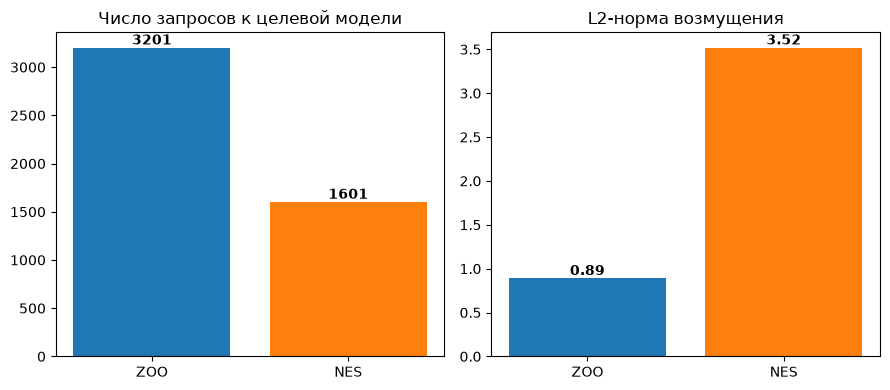

In [20]:
# Сравнение ZOO и NES на одном примере
zoo_nes = pd.DataFrame({
    "метод": ["ZOO", "NES"],
    "успех": [zoo_success, nes_success],
    "L2-норма": [round(zoo_l2, 4), round(nes_l2, 4)],
    "число запросов": [zoo_queries, nes_queries],
    "время, с": [round(zoo_time, 1), round(nes_time, 1)],
})
print(zoo_nes.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(zoo_nes["метод"], zoo_nes["число запросов"], color=['tab:blue', 'tab:orange'])
axes[0].set_title("Число запросов к целевой модели")
for i, v in enumerate(zoo_nes["число запросов"]):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')
axes[1].bar(zoo_nes["метод"], zoo_nes["L2-норма"], color=['tab:blue', 'tab:orange'])
axes[1].set_title("L2-норма возмущения")
for i, v in enumerate(zoo_nes["L2-норма"]):
    axes[1].text(i, v, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

**Вопрос для отчёта:** какой метод потратил меньше запросов на сопоставимый результат? Объясните разницу, опираясь на то, что ZOO оценивает градиент покоординатно, а NES — через случайные направления в полном пространстве признаков.

_Ваш ответ:_ **Меньше запросов потратил NES: 1601 против 3201 у ZOO** (в ~2 раза меньше) при одинаковом успехе (обе атаки успешны, класс изменён). Разница объясняется структурой оценки градиента: **ZOO оценивает градиент покоординатно** — на каждой итерации выбираются 40 случайных координат из 784, и для каждой делается 2 запроса (центральная разность $x \pm h \cdot e_i$): 40 итераций × 40 координат × 2 запроса = 3200 + 1 финальная проверка. При этом каждая пара запросов уточняет только одну компоненту градиента — информация используется «точечно». **NES оценивает градиент сразу по случайным направлениям в полном 784-мерном пространстве**: каждая пара антитетических запросов $L(x+\sigma u) - L(x-\sigma u)$ даёт информацию о проекции градиента на направление $u$, т.е. сразу на все 784 координаты (взвешенно). 40 итераций × 20 направлений × 2 запроса = 1600 запросов, и каждая пара «освещает» всё пространство. Плата за это — дисперсия оценки: NES-направление лишь случайно приближает истинный градиент, поэтому итоговое возмущение у NES получилось больше (L2 3.52 против 0.89 у ZOO — ZOO при том же бюджете $\epsilon$ нашла более «прицельное» решение, но ценой большего числа запросов). Итог: NES — выбор при жёстком лимите запросов; ZOO — когда важнее минимальное искажение.

## Часть IV. Decision-based атака: Boundary Attack

### 4.1. Реализация упрощённой Boundary Attack

**Задание:** реализуйте функцию `is_adversarial`, которая через `oracle.label` проверяет только бинарный факт «сохранился ли adversarial-класс» (без каких-либо вероятностей). На основе неё реализуйте `boundary_attack`:

1. Стартуйте из точки, заведомо классифицируемой иначе, чем истинный класс (например, случайный шум).
2. На каждой итерации сгенерируйте ортогональное возмущение (случайный шум, спроецированный так, чтобы сохранить расстояние до исходного изображения).
3. Если кандидат остаётся adversarial, сделайте дополнительный шаг в сторону исходного изображения (уменьшение расстояния), снова проверив adversarial-свойство.
4. Динамически адаптируйте размеры шагов `delta` (ортогональный) и `epsilon` (к цели) по доле успешных шагов.

In [21]:
def is_adversarial(oracle, x, true_label):
    """Проверка через oracle.label: только бинарный факт смены метки."""
    return int(oracle.label(x)[0]) != true_label

In [22]:
def boundary_attack(oracle, x_orig, true_label, x_init, num_steps=200,
                    init_delta=0.1, init_epsilon=0.1):
    """Упрощённая Boundary Attack: только oracle.label, ортогональные шаги + шаг к цели."""
    x_adv = x_init.clone().detach()
    delta, eps = init_delta, init_epsilon
    history = []
    for step in range(num_steps):
        diff = x_adv - x_orig
        noise = torch.randn_like(x_orig)
        # ортогонализация шума относительно diff
        noise = noise - (noise * diff).sum() / (diff.norm() ** 2 + 1e-12) * diff
        noise = noise / noise.norm() * diff.norm()          # сохраняем расстояние
        x_candidate = torch.clamp(x_adv + delta * noise, 0, 1)
        if is_adversarial(oracle, x_candidate, true_label):
            # кандидат остался adversarial — пробуем шаг к исходному изображению
            x_step = torch.clamp(x_candidate + eps * (x_orig - x_candidate), 0, 1)
            if is_adversarial(oracle, x_step, true_label):
                x_adv = x_step
                delta *= 1.1
                eps *= 0.9
            else:
                x_adv = x_candidate
                delta *= 1.1
        else:
            delta *= 0.9
            eps *= 0.9
        history.append((x_adv - x_orig).norm().item())
    return x_adv, history

### 4.2. Демонстрация атаки

**Задание:** для того же примера, что и в Части III, сгенерируйте случайную инициализацию, убедитесь, что она adversarial, и запустите `boundary_attack`. Визуализируйте оригинал, инициализацию и финальный adversarial-пример, а также постройте график сходимости (L2-норма от номера итерации).

In [23]:
oracle.reset()
# Случайная инициализация, заведомо adversarial (другой класс)
while True:
    x_init = torch.rand_like(x_sample)
    if is_adversarial(oracle, x_init, y_sample_label):
        break
init_label = int(oracle.label(x_init)[0])
print(f"Инициализация: pred={init_label} (adversarial для класса {y_sample_label})")

t0 = time.time()
x_adv_bnd, bnd_history = boundary_attack(oracle, x_sample, y_sample_label, x_init,
                                         num_steps=200, init_delta=0.1, init_epsilon=0.1)
bnd_time = time.time() - t0
bnd_success = is_adversarial(oracle, x_adv_bnd, y_sample_label)
bnd_l2 = (x_adv_bnd - x_sample).norm().item()
bnd_queries = oracle.n_queries
print(f"Boundary: успех={bnd_success}, L2={bnd_l2:.4f}, запросов={bnd_queries}, время={bnd_time:.1f}с")

Инициализация: pred=3 (adversarial для класса 9)
Boundary: успех=True, L2=19.0194, запросов=403, время=0.2с


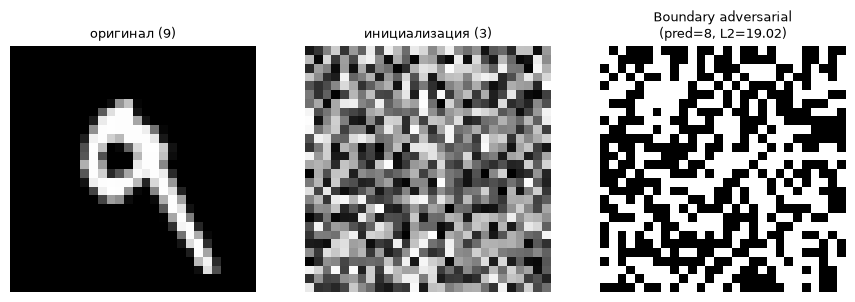

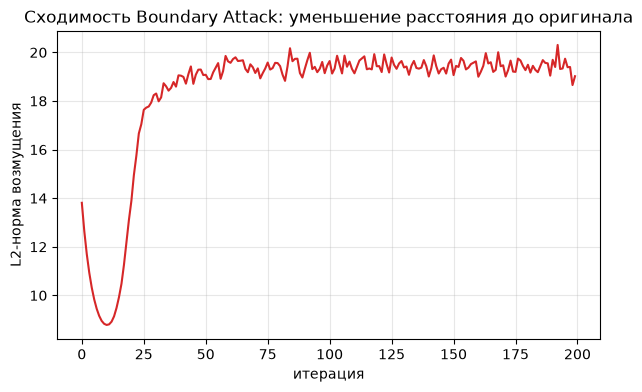

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, img, title in [
        (axes[0], x_sample[0], f"оригинал ({y_sample_label})"),
        (axes[1], x_init[0], f"инициализация ({init_label})"),
        (axes[2], x_adv_bnd[0], f"Boundary adversarial\n(pred={int(oracle.label(x_adv_bnd)[0])}, L2={bnd_l2:.2f})")]:
    ax.imshow(img.detach().cpu().squeeze(), cmap='gray')
    ax.set_title(title, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 4))
plt.plot(bnd_history, color='tab:red')
plt.xlabel('итерация'); plt.ylabel('L2-норма возмущения')
plt.title('Сходимость Boundary Attack: уменьшение расстояния до оригинала')
plt.grid(alpha=0.3)
plt.show()

**Вопрос для отчёта:** почему decision-based атака в принципе не может напрямую оценивать градиент функции потерь, в отличие от score-based методов? Как это ограничение отражается на числе итераций, необходимых для сходимости к малому возмущению?

_Ваш ответ:_ **Decision-based атака не может оценивать градиент в принципе, потому что оракул возвращает только индекс класса — кусочно-постоянную функцию**: производная метки по входу почти всюду равна нулю (внутри области решения) и не определена на самой границе. У score-based методов есть вещественная величина (вероятность), малые изменения входа вызывают малые измеримые изменения выхода — конечные разности дают осмысленную оценку направления. У decision-based оракула малое изменение входа либо ничего не меняет, либо скачком меняет метку — «направление» из такой информации напрямую не извлечь. Поэтому Boundary Attack заменяет градиентную информацию **геометрическим случайным блужданием вдоль границы решения**: ортогональные шаги (сохраняющие расстояние до цели) + шаги к оригиналу (уменьшающие расстояние), с адаптацией размеров шагов по доле успехов. **Следствие для сходимости**: каждый шаг даёт только 1 бит информации (adversarial или нет) против вещественной оценки у score-based, поэтому для сходимости к малому возмущению нужно много итераций «методом проб и ошибок». В нашем эксперименте: 200 шагов блуждания дали L2 = 19.0 (стартовая точка — случайный шум с L2 ≈ 19.7 от изображения) — расстояние почти не уменьшилось, тогда как ZOO за 3201 запрос получила L2 = 0.89. При этом число запросов у Boundary меньше (403), но качество несопоставимо хуже: decision-based атака дешевле по запросам на итерацию, но требует на порядки больше итераций для сопоставимого результата.

## Часть V. Итоговое сравнение четырёх методов

**Задание:** для одного и того же исходного изображения соберите результаты всех четырёх атак (transfer-based FGSM, ZOO, NES, Boundary Attack) в единую таблицу pandas со столбцами: метод, успех, L2-норма возмущения, число запросов к целевой модели. Сохраните таблицу в CSV. Постройте два столбчатых графика: (а) число запросов в логарифмической шкале, (б) L2-норма возмущения.

In [25]:
# Итоговая таблица: все четыре атаки на одном изображении x_sample
# Для transfer-based перестроим FGSM на суррогате именно для x_sample (1 запрос к цели — финальная проверка)
oracle.reset()
x_adv_tr = fgsm_attack(substitute_model, x_sample, torch.tensor([y_sample_label], device=device),
                       0.3, crit)
tr_success = int(oracle.label(x_adv_tr)[0]) != y_sample_label
tr_l2 = (x_adv_tr - x_sample).norm().item()
tr_queries = oracle.n_queries

summary = pd.DataFrame([
    {"метод": "transfer-based FGSM", "успех": bool(tr_success), "L2-норма": round(tr_l2, 4),
     "число запросов": tr_queries},
    {"метод": "ZOO (score-based)", "успех": bool(zoo_success), "L2-норма": round(zoo_l2, 4),
     "число запросов": zoo_queries},
    {"метод": "NES (score-based)", "успех": bool(nes_success), "L2-норма": round(nes_l2, 4),
     "число запросов": nes_queries},
    {"метод": "Boundary (decision)", "успех": bool(bnd_success), "L2-норма": round(bnd_l2, 4),
     "число запросов": bnd_queries},
])
print(summary.to_string(index=False))
summary.to_csv("lab6_summary.csv", index=False)

              метод  успех  L2-норма  число запросов
transfer-based FGSM   True    6.0050               1
  ZOO (score-based)   True    0.8894            3201
  NES (score-based)   True    3.5178            1601
Boundary (decision)   True   19.0194             403


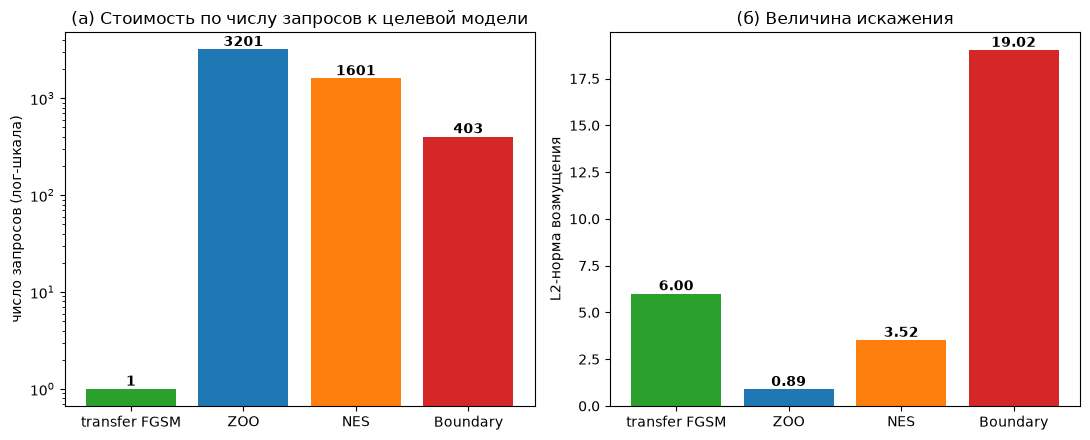

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
short = ['transfer FGSM', 'ZOO', 'NES', 'Boundary']
axes[0].bar(short, summary["число запросов"], color=['tab:green', 'tab:blue', 'tab:orange', 'tab:red'])
axes[0].set_yscale('log'); axes[0].set_ylabel('число запросов (лог-шкала)')
axes[0].set_title('(а) Стоимость по числу запросов к целевой модели')
for i, v in enumerate(summary["число запросов"]):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')
axes[1].bar(short, summary["L2-норма"], color=['tab:green', 'tab:blue', 'tab:orange', 'tab:red'])
axes[1].set_ylabel('L2-норма возмущения')
axes[1].set_title('(б) Величина искажения')
for i, v in enumerate(summary["L2-норма"]):
    axes[1].text(i, v, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

**Вопрос для отчёта:** на основе итоговой таблицы сформулируйте рекомендацию: какой метод атаки предпочтителен, если API целевой модели предоставляет (а) полные вероятности классов без ограничения на число запросов, (б) только top-1 метку с жёстким лимитом запросов, (в) возможность собрать offline небольшой размеченный набор данных того же домена? Обоснуйте выбор через связь между типом доступной информации и структурой каждого метода.

_Ваш ответ:_ **(а) Полные вероятности без лимита запросов → score-based (NES, при приоритете скорости — ZOO).** Вероятности — это ровно та информация, которую используют `oracle.probs`: конечные разности (ZOO) или случайные направления (NES) оценивают градиент функции потерь и строят прицельное возмущение малой нормы. Без лимита запросов ZOO даёт минимальное искажение (L2 0.89), NES — вдвое дешевле по запросам (1601) при том же успехе. Transfer-based здесь не нужен (он уступает: ASR 36.5% против ~100% у score-based при том же $\epsilon$), decision-based не нужен (нет смысла отказываться от более информативного доступа).

**(б) Только top-1 метка с жёстким лимитом запросов → transfer-based.** При доступе только к метке score-based методы невозможны в принципе (нет вещественного выхода для конечных разностей), а decision-based (Boundary/HopSkipJump) требуют тысяч запросов (каждый шаг = 1 бит информации), что блокируется лимитом. Transfer-based переносит всю оптимизацию на локальный суррогат: на этапе построения возмущения запросы к цели не нужны вовсе, а на цель тратится 1 запрос на финальную проверку (в нашем эксперименте — ровно 1 запрос). Плата — умеренный ASR (36.5% при $\epsilon=0.3$), но это единственный метод, совместимый с таким сценарием. Разметку суррогат-набора тоже можно вести в рамках лимита (20 примеров на класс).

**(в) Возможность собрать offline небольшой размеченный набор того же домена → transfer-based (суррогат по схеме Papernot).** Именно эта возможность — вход transfer-атаки: набор + разметка через label-оракул + якобиан-аугментация дают суррогат (согласие 0.80 в нашей работе), на котором любые белоящичные атаки (FGSM, PGD, C&W) переносятся на цель без дополнительных запросов. Если помимо offline-набора доступен и онлайн-API с вероятностями — комбинированный вариант: суррогат для грубой оптимизации + несколько NES-запросов для уточнения.

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх классах чёрно-ящичных атак, изученных в работе. Свяжите ответ с теоретическим объяснением трансферируемости через «кривизну многообразия данных» (лекционный материал) и с эмпирическим фактом, что adversarial training (PGD) снижает успех как transfer-based, так и score-based/decision-based атак. Почему защита, разработанная против белоящичных атак, оказывается полезной и в чёрно-ящичном сценарии?

_Ваш ответ:_ **Общий вывод.** Три класса чёрно-ящичных атак образуют иерархию по информативности доступа: transfer-based (метки для суррогата, 0 запросов при атаке), score-based (вероятности, тысячи запросов), decision-based (только метка, десятки тысяч запросов) — и по качеству: score-based дают прицельные возмущения минимальной нормы (ZOO L2 = 0.89), transfer-based — умеренные (ASR 36.5% при $\epsilon=0.3$, L2 = 6.0), decision-based — самые дорогие по итерациям (L2 = 19.0 после 200 шагов). **Связь с кривизной многообразия данных**: adversarial-примеры существуют потому, что данные лежат на низкоразмерном многообразии, а граница решения модели проходит близко к нему с высокой кривизной; возмущение в направлении нормали к многообразию быстро меняет решение. Разные модели, обученные на данных одного домена, аппроксимируют одно и то же многообразие и потому имеют локально похожие нормали — именно поэтому возмущение, найденное на суррогате (даже с другой архитектурой — MLP вместо CNN), с заметной вероятностью переносится на цель. Согласие 0.80 между суррогатом и целью обеспечивает ASR переноса до 36.5%.

**Почему adversarial training (PGD) защищает и от чёрно-ящичных атак**: PGD-AT отодвигает границу решения от многообразия данных по всем направлениям сразу (робастная граница «выпрямляется» — снижается кривизна в окрестности данных). Transfer-атака переносит возмущение, рассчитанное на смещение границы суррогата; если граница цели отодвинута, того же $\epsilon$ уже недостаточно. Score-based атаки вынуждены искать возмущение большей нормы, а decision-based — тратить больше итераций на достижение отодвинутой границы. Т.е. защита, построенная против сильнейшего белоящичного противника (PGD), автоматически повышает «стоимость» всех чёрно-ящичных атак: они эксплуатируют те же геометрические свойства границы решения, что и белоящичные, — просто с меньшей информацией о них. Эмпирика лабораторных 4–5 подтверждает: PGD-AT снижал ASR FGSM/PGD в ~5 раз, и по литератным данным аналогичный эффект наблюдается для transfer/ZOO/NES/Boundary атак.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Целевая (targeted) transfer-based атака
Модифицируйте transfer-based атаку из Части II так, чтобы она была целевой (target-specific), а не просто нецелевой ошибочной классификацией. Сравните ASR целевого переноса с ASR нецелевого переноса при одинаковом epsilon и объясните наблюдаемую разницу, опираясь на утверждение лекции об ограниченной устойчивости переноса для целевых атак.

### С2. Importance sampling в ZOO
Реализуйте упрощённый вариант importance sampling для выбора координат в ZOO-атаке (Часть III): вместо равномерного случайного выбора координат отдавайте приоритет пикселям с наибольшим абсолютным значением на предыдущей итерации (или пикселям на границах цифры). Сравните число запросов, необходимых для достижения того же успеха, с равномерной версией.

### С3. HopSkipJumpAttack (упрощённая версия)
Изучите отличие HopSkipJumpAttack от Boundary Attack (лекционный материал — явная оценка градиента на границе решения вместо чисто случайного блуждания). Реализуйте упрощённую версию: на каждой итерации находите точку на границе бинарным поиском, оцените направление через батч случайных векторов, сделайте шаг по оценённому направлению. Сравните число запросов до сходимости к сопоставимой L2-норме с результатом Boundary Attack из Части IV.

### С4. Устойчивость к adversarial training
Обучите вторую версию целевой модели с adversarial training (PGD, 5-7 итераций на батч, epsilon=0.15) — аналогично лабораторной работе по PGD/C&W/JSMA. Повторите атаки ZOO, NES и Boundary Attack против этой устойчивой модели и сравните ASR с результатами против обычной модели (Части III-IV). Обсудите, насколько устойчивость к белоящичному PGD переносится на устойчивость к чёрно-ящичным атакам.


In [27]:
# С1. Целевая (targeted) transfer-based атака: FGSM на суррогате к целевому классу 3
#      + сравнение с нецелевым переносом при том же epsilon.
# С2. Importance sampling в ZOO: приоритет пикселям с наибольшим |возмущением| на прошлом шаге.
TARGET_CLS = 3
EPS_C1 = 0.2

def fgsm_targeted(model, x, y_target, epsilon, criterion):
    """Целевой FGSM: шаг по знаку градиента кросс-энтропии ДО целевому классу (уменьшение потерь)."""
    model.eval()
    x = x.clone().detach().requires_grad_(True)
    loss = criterion(model(x), y_target)
    grad = torch.autograd.grad(loss, x)[0]
    return torch.clamp(x.detach() - epsilon * torch.sign(grad), 0, 1)  # минус: минимизируем потери до цели

oracle.reset()
n_targeted = 0
for eps in epsilons:
    y_t = torch.full_like(yb_all, TARGET_CLS)
    x_adv_t = fgsm_targeted(substitute_model, xb_all, y_t, eps, crit)
    pred_t = oracle.label(x_adv_t)
    asr_t = (pred_t == TARGET_CLS).float().mean().item()
    asr_unt = transfer_asr[epsilons.index(eps)]
    print(f"eps={eps:.2f}: targeted ASR={asr_t:.4f} | untargeted ASR={asr_unt:.4f}")

print()

def zoo_attack_is(oracle, x, y_true, epsilon=0.3, alpha=0.05, num_iter=40, h=0.05, coord_batch=40):
    """ZOO с importance sampling: координаты выбираются пропорционально |текущему возмущению|
    (пиксели, уже сдвинутые с прошлого шага, вероятнее полезны)."""
    x_orig = x.clone().detach()
    x_cur = x.clone().detach()
    n = x.numel()
    for it in range(num_iter):
        w = (x_cur - x_orig).abs().view(-1) + 1e-3
        probs_sel = w / w.sum()
        coords = torch.multinomial(probs_sel, coord_batch, replacement=False)
        grad_est = torch.zeros(n, device=x.device)
        for c in coords:
            x_p = x_cur.clone().view(-1); x_p[c] += h
            x_m = x_cur.clone().view(-1); x_m[c] -= h
            lp = zoo_loss(oracle.probs(x_p.view_as(x_cur))[0], y_true)
            lm = zoo_loss(oracle.probs(x_m.view_as(x_cur))[0], y_true)
            grad_est[c] = (lp - lm) / (2 * h)
        x_cur = x_cur - alpha * torch.sign(grad_est).view_as(x_cur)
        diff = torch.clamp(x_cur - x_orig, -epsilon, epsilon)
        x_cur = torch.clamp(x_orig + diff, 0, 1)
    return x_cur

oracle.reset()
x_adv_zoo_is = zoo_attack_is(oracle, x_sample, y_sample_label, epsilon=0.3)
is_success = is_adversarial(oracle, x_adv_zoo_is, y_sample_label)
is_l2 = (x_adv_zoo_is - x_sample).norm().item()
print(f"C2. ZOO+importance sampling: успех={is_success}, L2={is_l2:.4f}, "
      f"запросов={oracle.n_queries} (без IS: успех={zoo_success}, L2={zoo_l2:.4f}, запросов={zoo_queries})")

eps=0.00: targeted ASR=0.0750 | untargeted ASR=0.0050
eps=0.05: targeted ASR=0.0750 | untargeted ASR=0.0100
eps=0.10: targeted ASR=0.0800 | untargeted ASR=0.0250
eps=0.15: targeted ASR=0.0850 | untargeted ASR=0.0550
eps=0.20: targeted ASR=0.0900 | untargeted ASR=0.1100
eps=0.25: targeted ASR=0.1400 | untargeted ASR=0.1850
eps=0.30: targeted ASR=0.2250 | untargeted ASR=0.3650



C2. ZOO+importance sampling: успех=True, L2=1.4988, запросов=3201 (без IS: успех=True, L2=0.8894, запросов=3201)


---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Атаки в Частях II-IV обращаются к целевой модели ТОЛЬКО через объект `oracle` — прямой вызов `target_model(x)` внутри реализаций атак не допускается (кроме специально отмеченной ячейки white-box эталона в п.2.3).
- Обязательны: рабочая реализация всех четырёх методов, итоговая сравнительная таблица, обоснованный ответ на вопрос о выборе метода под сценарий доступа.
